<a href="https://colab.research.google.com/github/shafiq73/2024/blob/main/Kaggle_style_Health_Awareness_Disease_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [ ]:
df = pd.read_csv('Health_Awareness_Disease_Prediction.csv')

In [ ]:
df.head()

,Age,Gender,Education_Level,Residence,Smoking,Physical_Activity,BMI_Category,Awareness_Source,Regular_Checkup,Chronic_Disease,Knowledge_Level
0,66,Male,Secondary,Urban,Yes,High,Underweight,Internet,Yes,No,Medium
1,29,Male,Secondary,Urban,No,Low,Obese,Friends,No,Yes,Low
2,75,Female,Secondary,Rural,Yes,Low,Normal,Friends,Yes,No,Low
3,35,Female,Post-Graduate,Urban,Yes,High,Obese,TV,No,No,Medium
4,38,Male,Primary,Urban,No,Low,Normal,Internet,Yes,Yes,High


In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Education_Level,0
Residence,0
Smoking,0
Physical_Activity,0
BMI_Category,0
Awareness_Source,0
Regular_Checkup,0
Chronic_Disease,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                500 non-null    int64 
 1   Gender             500 non-null    object
 2   Education_Level    500 non-null    object
 3   Residence          500 non-null    object
 4   Smoking            500 non-null    object
 5   Physical_Activity  500 non-null    object
 6   BMI_Category       500 non-null    object
 7   Awareness_Source   500 non-null    object
 8   Regular_Checkup    500 non-null    object
 9   Chronic_Disease    500 non-null    object
 10  Knowledge_Level    500 non-null    object
dtypes: int64(1), object(10)
memory usage: 43.1+ KB


In [ ]:
df.describe()

,Age
count,500.000000
mean,47.296000
std,19.295518
min,15.000000
25%,31.000000
50%,47.000000
75%,65.000000
max,79.000000


In [ ]:
df.columns

Index(['Age', 'Gender', 'Education_Level', 'Residence', 'Smoking',
       'Physical_Activity', 'BMI_Category', 'Awareness_Source',
       'Regular_Checkup', 'Chronic_Disease', 'Knowledge_Level'],
      dtype='object')

In [ ]:
df.Age.unique()

array([66, 29, 75, 35, 38, 17, 36, 67, 16, 44, 52, 78, 74, 47, 72, 63, 73,
       56, 76, 61, 65, 69, 21, 53, 32, 18, 28, 23, 58, 22, 49, 50, 64, 20,
       68, 77, 48, 62, 54, 40, 55, 43, 59, 79, 15, 25, 19, 42, 26, 37, 51,
       41, 57, 27, 46, 71, 70, 33, 31, 30, 34, 45, 39, 60, 24])

In [ ]:
df.Age.value_counts()

,count
Age,
76,18
47,15
72,14
33,13
38,13
...,...
55,3
25,3
70,3


In [ ]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 2})

In [ ]:
df['Education_Level'] = df['Education_Level'].map({'Primary': 0, 'Secondary': 1, 'Graduate': 2, 'Post-Graduate':3})

In [ ]:
df['Residence'] = df['Residence'].map({'Urban': 1, 'Rural': 2})

In [ ]:
df['Smoking'] = df['Smoking'].map({'Yes': 1, 'No': 2})

In [ ]:
df['Physical_Activity'] = df['Physical_Activity'].map({'Low': 1, 'Moderate': 2, 'High': 3})

In [ ]:
# Step 1: Check mode
mode_value = df['BMI_Category'].mode()[0]
print("Mode of BMI_Category:", mode_value)

# Step 2: Fill NaN with mode
df['BMI_Category'].fillna(mode_value, inplace=True)

# Step 3: Verify
print(df['BMI_Category'].isna().sum())  # Should be 0


Mode of BMI_Category: Normal
0


/tmp/ipython-input-2898816512.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['BMI_Category'].fillna(mode_value, inplace=True)


In [ ]:
df['BMI_Category'] = df['BMI_Category'].map({'Underweight': 0, 'Normal': 1, 'Overweight': 2, 'Obese':3})

In [ ]:
df['Awareness_Source'] = df['Awareness_Source'].map({'Friends': 0, 'Social Media': 1, 'Internet': 2, 'TV':3, 'Doctor':4})

In [ ]:
df['Regular_Checkup'] = df['Regular_Checkup'].map({'Yes': 1, 'No': 2})

In [ ]:
df['Chronic_Disease'] = df['Chronic_Disease'].map({'Yes': 1, 'No': 2})

In [ ]:
df['Knowledge_Level'] = df['Knowledge_Level'].map({'Low': 0, 'Medium': 1, 'High': 2})

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

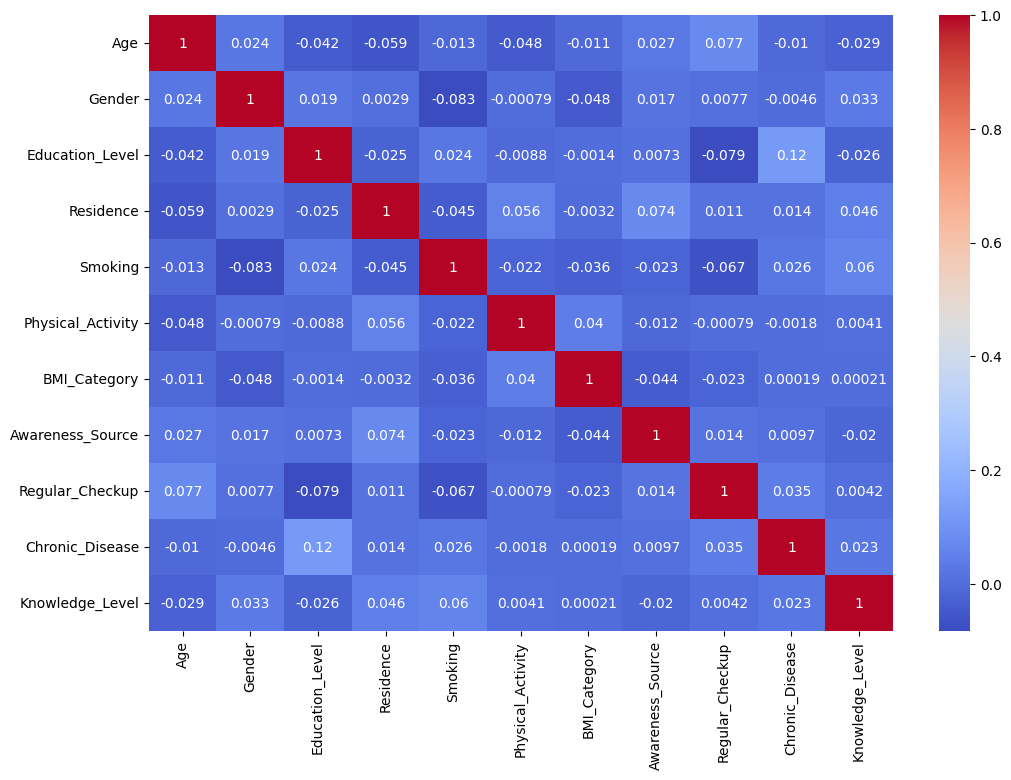

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

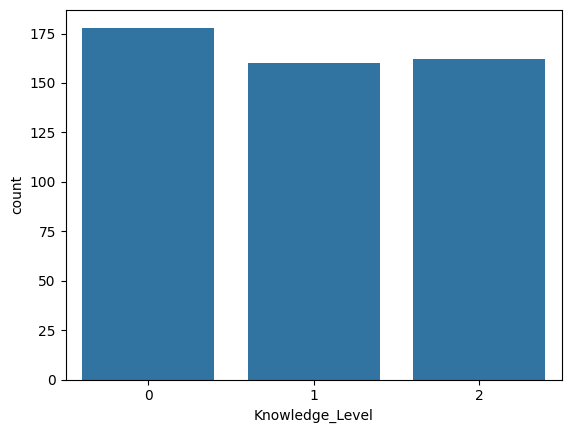

In [ ]:
sns.countplot(x='Knowledge_Level', data=df)
plt.show()

In [ ]:
# Drop useless columns before H2O
# df_clean = df.drop(['Physical_Activity','Smoking'], axis=1)



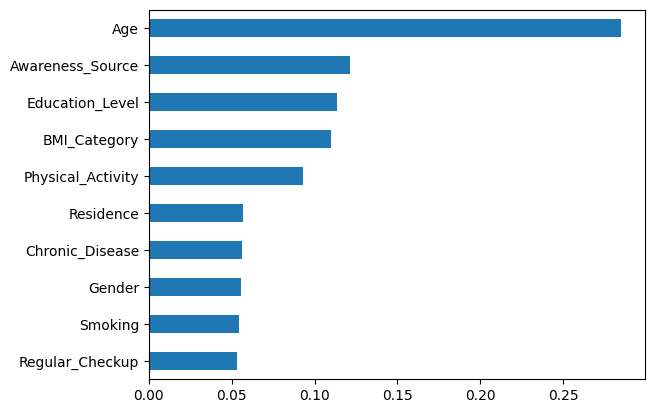

In [ ]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop('Knowledge_Level', axis=1)
y = df['Knowledge_Level']

model = RandomForestClassifier()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.33
              precision    recall  f1-score   support

           0       0.44      0.38      0.41        42
           1       0.32      0.31      0.31        36
           2       0.20      0.27      0.23        22

    accuracy                           0.33       100
   macro avg       0.32      0.32      0.32       100
weighted avg       0.35      0.33      0.34       100



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(len(y.unique()), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.3334 - loss: 11.2771 - val_accuracy: 0.3000 - val_loss: 3.8517
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3165 - loss: 3.1237 - val_accuracy: 0.2500 - val_loss: 1.8792
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3573 - loss: 1.5625 - val_accuracy: 0.3500 - val_loss: 1.5682
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3469 - loss: 1.3122 - val_accuracy: 0.2875 - val_loss: 1.5016
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3449 - loss: 1.3541 - val_accuracy: 0.3125 - val_loss: 1.4005
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3640 - loss: 1.2404 - val_accuracy: 0.2625 - val_loss: 1.3696
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3805 - loss: 1.2149 - val_accuracy: 0.3375 - val_loss: 1.3240
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4275 - loss: 1.1406 - val_accuracy: 0.3500 - val_loss: 1.3072
E

In [ ]:
# !pip install h2o

In [ ]:
# Example H2O
import h2o
from h2o.automl import H2OAutoML

h2o.init()
hf = h2o.H2OFrame(df)
x = hf.columns
y = 'Knowledge_Level'
x.remove(y)

aml = H2OAutoML(max_models=10, seed=42)
aml.train(x=x, y=y, training_frame=hf)


Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.17" 2025-10-21; OpenJDK Runtime Environment (build 17.0.17+10-Ubuntu-122.04); OpenJDK 64-Bit Server VM (build 17.0.17+10-Ubuntu-122.04, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpk92ov2pq
  JVM stdout: /tmp/tmpk92ov2pq/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpk92ov2pq/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,07 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,1 month and 29 days
H2O_cluster_name:,H2O_from_python_unknownUser_w068ub
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.168 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


key,value
Stacking strategy,cross_validation
Number of base models (used / total),0/5
# GBM base models (used / total),0/1
# XGBoost base models (used / total),0/1
# GLM base models (used / total),0/1
# DRF base models (used / total),0/2
Metalearner algorithm,GLM
Metalearner fold assignment scheme,Random
Metalearner nfolds,5
Metalearner fold_column,None


In [ ]:
# List all models
aml.leaderboard

model_id,rmse,mse,mae,rmsle,mean_residual_deviance
StackedEnsemble_BestOfFamily_1_AutoML_1_20260123_55638,0.824576,0.679926,0.689387,0.470175,0.679926
StackedEnsemble_AllModels_1_AutoML_1_20260123_55638,0.826467,0.683047,0.690377,0.471062,0.683047
GLM_1_AutoML_1_20260123_55638,0.828019,0.685616,0.693097,0.47188,0.685616
GBM_1_AutoML_1_20260123_55638,0.835102,0.697396,0.703103,0.474952,0.697396
XRT_1_AutoML_1_20260123_55638,0.850441,0.72325,0.733265,0.483113,0.72325
GBM_4_AutoML_1_20260123_55638,0.860042,0.739672,0.743425,0.486971,0.739672
GBM_3_AutoML_1_20260123_55638,0.860276,0.740075,0.740904,0.487078,0.740075
DRF_1_AutoML_1_20260123_55638,0.865028,0.748274,0.744553,0.486237,0.748274
GBM_2_AutoML_1_20260123_55638,0.870033,0.756957,0.752632,0.492286,0.756957
XGBoost_1_AutoML_1_20260123_55638,0.966746,0.934597,0.834376,0.542078,0.934597


In [ ]:
# Leaderboard print karo
lb = aml.leaderboard
print(lb)

model_id                                                    rmse       mse       mae     rmsle    mean_residual_deviance
StackedEnsemble_BestOfFamily_1_AutoML_1_20260123_55638  0.824576  0.679926  0.689387  0.470175                  0.679926
StackedEnsemble_AllModels_1_AutoML_1_20260123_55638     0.826467  0.683047  0.690377  0.471062                  0.683047
GLM_1_AutoML_1_20260123_55638                           0.828019  0.685616  0.693097  0.47188                   0.685616
GBM_1_AutoML_1_20260123_55638                           0.835102  0.697396  0.703103  0.474952                  0.697396
XRT_1_AutoML_1_20260123_55638                           0.850441  0.72325   0.733265  0.483113                  0.72325
GBM_4_AutoML_1_20260123_55638                           0.860042  0.739672  0.743425  0.486971                  0.739672
GBM_3_AutoML_1_20260123_55638                           0.860276  0.740075  0.740904  0.487078                  0.740075
DRF_1_AutoML_1_20260123_55638    

In [ ]:
# Leaderboard as H2OFrame
lb = aml.leaderboard

# Convert to pandas
lb_df = lb.as_data_frame()
print(lb_df.columns)  # Check exact column names
print(lb_df.head())


Index(['model_id', 'rmse', 'mse', 'mae', 'rmsle', 'mean_residual_deviance'], dtype='object')
                                            model_id      rmse       mse  \
0  StackedEnsemble_BestOfFamily_1_AutoML_1_202601...  0.824576  0.679926   
1  StackedEnsemble_AllModels_1_AutoML_1_20260123_...  0.826467  0.683047   
2                      GLM_1_AutoML_1_20260123_55638  0.828019  0.685616   
3                      GBM_1_AutoML_1_20260123_55638  0.835102  0.697396   
4                      XRT_1_AutoML_1_20260123_55638  0.850441  0.723250   

        mae     rmsle  mean_residual_deviance  
0  0.689387  0.470175                0.679926  
1  0.690377  0.471062                0.683047  
2  0.693097  0.471880                0.685616  
3  0.703103  0.474952                0.697396  
4  0.733265  0.483113                0.723250  


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [ ]:
# Convert leaderboard to pandas
lb_df = aml.leaderboard.as_data_frame()

# Pick the GBM model by checking model_id string
gbm_model_id = lb_df[lb_df['model_id'].str.contains('GBM')]['model_id'].values[0]

# Load GBM model
gbm_model = h2o.get_model(gbm_model_id)

# Feature importance
var_imp = gbm_model.varimp()
print(var_imp)


[('Age', 14.259076118469238, 1.0, 0.3378387743788451), ('BMI_Category', 8.949432373046875, 0.6276305911190849, 0.2120379496663417), ('Chronic_Disease', 4.934576511383057, 0.3460656546318234, 0.11691439661542792), ('Smoking', 4.238880157470703, 0.29727593304451494, 0.10043133687208654), ('Awareness_Source', 3.576667308807373, 0.250834435491557, 0.0847415982584771), ('Residence', 2.572450637817383, 0.18040794624031675, 0.06094879944603319), ('Education_Level', 2.016541004180908, 0.14142157510253833, 0.047777691603367346), ('Physical_Activity', 1.1782358884811401, 0.08263059111908493, 0.027915817629871133), ('Gender', 0.480888307094574, 0.033725067676137706, 0.011393635529549967), ('Regular_Checkup', 0.0, 0.0, 0.0)]


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,1 min 15 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,1 month and 29 days
H2O_cluster_name:,H2O_from_python_unknownUser_w068ub
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.144 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


AutoML Leaderboard:
                                              model_id      rmse       mse  \
0   StackedEnsemble_BestOfFamily_1_AutoML_1_202601...  0.824576  0.679926   
1   StackedEnsemble_AllModels_1_AutoML_1_20260123_...  0.826467  0.683047   
2                       GLM_1_AutoML_1_20260123_55638  0.828019  0.685616   
3                       GBM_1_AutoML_1_20260123_55638  0.835102  0.697396   
4                       XRT_1_AutoML_1_20260123_55638  0.850441  0.723250   
5                       GBM_4_AutoML_1_20260123_55638  0.860042  0.739672   
6                       GBM_3_AutoML_1_20260123_55638  0.860276  0.740075   
7                       DRF_1_AutoML_1_20260123_55638  0.865028  0.748274   
8                       GBM_2_AutoML_1_20260123_55638  0.870033  0.756957   
9                   XGBoost_1_AutoML_1_20260123_55638  0.966746  0.934597   
10                  XGBoost_3_AutoML_1_20260123_55638  0.973956  0.948591   
11                  XGBoost_2_AutoML_1_20260123_55638  

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/tmp/ipython-input-2878780396.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='percentage', y='variable', data=varimp, palette='viridis')


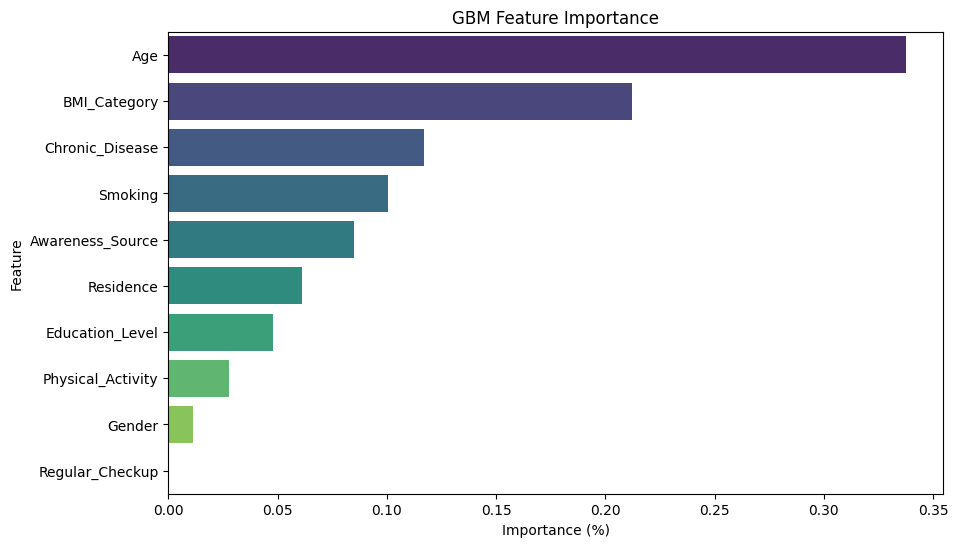

✅ Leaderboard and feature importance saved as CSV.


In [ ]:
import h2o
from h2o.automl import H2OAutoML
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1️⃣ Connect to H2O
h2o.init()

# Assume hf is your H2OFrame from your cleaned dataset
# hf = h2o.H2OFrame(df)

# 2️⃣ AutoML Leaderboard
aml_leaderboard = aml.leaderboard
lb_df = aml_leaderboard.as_data_frame()
print("AutoML Leaderboard:\n", lb_df)

# 3️⃣ Feature Importance
# Pick the first GBM model from leaderboard
gbm_models = [mid for mid in lb_df['model_id'] if 'GBM' in mid]
if gbm_models:
    gbm_model = h2o.get_model(gbm_models[0])
    varimp = gbm_model.varimp(use_pandas=True)
    print("\nFeature Importance:\n", varimp)

    # 4️⃣ Plot Feature Importance
    plt.figure(figsize=(10,6))
    sns.barplot(x='percentage', y='variable', data=varimp, palette='viridis')
    plt.title('GBM Feature Importance')
    plt.xlabel('Importance (%)')
    plt.ylabel('Feature')
    plt.show()
else:
    print("No GBM model found in leaderboard for variable importance.")

# 5️⃣ Optional: Save Leaderboard & Feature Importance as CSV
lb_df.to_csv('AutoML_Leaderboard.csv', index=False)
if gbm_models:
    varimp.to_csv('GBM_Feature_Importance.csv', index=False)

print("✅ Leaderboard and feature importance saved as CSV.")


## AI codes

In [ ]:
# -------------------------
# 1️⃣ Libraries
# -------------------------
import pandas as pd
import numpy as np
import h2o
from h2o.automl import H2OAutoML

# -------------------------
# 2️⃣ Start H2O
# -------------------------
h2o.init(max_mem_size="4G")

# -------------------------
# 3️⃣ Load your dataset
# -------------------------
# Replace 'your_data.csv' with your CSV file
df = pd.read_csv('Health_Awareness_Disease_Prediction.csv')

# -------------------------
# 4️⃣ Data Cleaning
# -------------------------
# Remove whitespace & lowercase for consistency
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# Fill missing numeric with median
for col in df.select_dtypes(include=['int64','float64']).columns:
    df[col].fillna(df[col].median(), inplace=True)

# Fill missing categorical with mode
for col in df.select_dtypes(include=['object']).columns:
    df[col].replace(['nan','NaN','NA',''], np.nan, inplace=True)
    df[col].fillna(df[col].mode()[0], inplace=True)

# -------------------------
# 5️⃣ Feature Engineering
# -------------------------
# Age bins
bins = [18, 30, 50, 80]
labels = ['Young','Adult','Old']
df['Age_Bin'] = pd.cut(df['Age'], bins=bins, labels=labels)

# One-hot encoding categorical features
categorical_cols = ['Gender','Education_Level','Residence','Smoking',
                    'Physical_Activity','BMI_Category','Awareness_Source',
                    'Regular_Checkup','Chronic_Disease','Age_Bin']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# -------------------------
# 6️⃣ Convert to H2O Frame
# -------------------------
hf = h2o.H2OFrame(df)

# -------------------------
# 7️⃣ Define target and features
# -------------------------
target = 'Knowledge_Level'  # replace with your target
features = [c for c in hf.columns if c != target]

# -------------------------
# 8️⃣ Convert target to categorical if classification
# -------------------------
hf[target] = hf[target].asfactor()

# -------------------------
# 9️⃣ Run H2O AutoML
# -------------------------
aml = H2OAutoML(max_models=20, seed=42, nfolds=5, exclude_algos=['DeepLearning'])
aml.train(x=features, y=target, training_frame=hf)

# -------------------------
# 10️⃣ Leaderboard & Feature Importance
# -------------------------
lb = aml.leaderboard
print(lb.head(10))

# Feature importance from leader model if tree-based
if hasattr(aml.leader, "varimp"):
    varimp = aml.leader.varimp(use_pandas=True)
    print(varimp)

# -------------------------
# ✅ Done
# -------------------------


Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.17" 2025-10-21; OpenJDK Runtime Environment (build 17.0.17+10-Ubuntu-122.04); OpenJDK 64-Bit Server VM (build 17.0.17+10-Ubuntu-122.04, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpfwj64ffv
  JVM stdout: /tmp/tmpfwj64ffv/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpfwj64ffv/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,04 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,1 month and 29 days
H2O_cluster_name:,H2O_from_python_unknownUser_u3entv
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.979 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


/tmp/ipython-input-1498112622.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
/tmp/ipython-input-1498112622.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-1498112622.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This in

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
model_id                                               mean_per_class_error    logloss      rmse       mse
StackedEnsemble_AllModels_1_AutoML_1_20260123_62536                0.627763    1.09514  0.662706  0.43918
DRF_1_AutoML_1_20260123_62536                                      0.645246    1.18939  0.678849  0.460835
XGBoost_1_AutoML_1_20260123_62536                                  0.64678     1.19796  0.679469  0.461679
GBM_grid_1_AutoML_1_20260123_62536_model_1                         0.649788    1.22655  0.686025  0.47063
XGBoost_grid_1_AutoML_1_20260123_62536_model_6                     0.656118    1.10996  0.668068  0.446315
GBM_4_AutoML_1_20260123_62536                                      0.656616    1.16247  0.676715  0.457943
XGBoost_2_AutoML_1_20260123_62536                              

In [ ]:
# Tree-based leader choose karo (GBM ya DRF)
tree_leader = aml.leader
if hasattr(tree_leader, "varimp"):
    varimp = tree_leader.varimp(use_pandas=True)
    print(varimp)
else:
    print("This model doesn't have variable importances")


None


In [ ]:
# H2O AutoML leader se individual model select karo
# Leaderboard ka top individual tree model select karo (GBM ya DRF)
leaderboard = aml.leaderboard
best_tree_model_id = leaderboard.as_data_frame().loc[leaderboard.as_data_frame()['model_id'].str.contains('GBM|DRF'),'model_id'].iloc[0]

best_tree_model = h2o.get_model(best_tree_model_id)

# Feature importance nikal lo
varimp = best_tree_model.varimp(use_pandas=True)
print(varimp)


                         variable  relative_importance  scaled_importance  \
0                             Age          1423.584717           1.000000   
1             Regular_Checkup_Yes           373.457611           0.262336   
2                     Smoking_Yes           361.183716           0.253714   
3             Chronic_Disease_Yes           357.936279           0.251433   
4                     Gender_Male           340.548950           0.239219   
5                 Residence_Urban           328.987488           0.231098   
6      Physical_Activity_Moderate           320.316406           0.225007   
7           Physical_Activity_Low           294.904419           0.207156   
8         Education_Level_Primary           283.434479           0.199099   
9       Education_Level_Secondary           278.711792           0.195782   
10       Awareness_Source_Friends           248.974640           0.174893   
11  Education_Level_Post-Graduate           248.746857           0.174733   

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [ ]:
aml = H2OAutoML(max_models=5, max_runtime_secs=300, seed=1)

H2OConnectionError: Not connected to a cluster. Did you run `h2o.init()` or `h2o.connect()`?

In [ ]:
# ==============================
# 1️⃣ Libraries Import
# ==============================
import h2o
from h2o.automl import H2OAutoML
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================
# 2️⃣ Start H2O cluster
# ==============================
h2o.init(max_mem_size="4G", nthreads=-1)

# ==============================
# 3️⃣ Load Dataset
# ==============================
df = pd.read_csv("Health_Awareness_Disease_Prediction.csv")  # change with your CSV path

# ==============================
# 4️⃣ Clean Dataset
# ==============================
# Strip strings and replace common nulls
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
for col in df.columns:
    df[col].replace(['nan','NaN','NA',''], np.nan, inplace=True)
    if df[col].dtype in ['float64','int64']:
        df[col].fillna(df[col].median(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

# ==============================
# 5️⃣ Convert to H2O Frame
# ==============================
hf = h2o.H2OFrame(df)

# ==============================
# 6️⃣ Identify Features and Target
# ==============================
target = "BMI_Category"  # <-- replace with your target column name
features = [c for c in hf.columns if c != target]

# Convert categorical columns to factors
for col in hf.columns:
    if hf[col].isfactor()[0] or df[col].dtype == 'object':
        hf[col] = hf[col].asfactor()

# ==============================
# 7️⃣ Run H2O AutoML
# ==============================
aml = H2OAutoML(max_runtime_secs=1200,   # 20 mins
                seed=42,
                nfolds=5,
                exclude_algos=None,
                keep_cross_validation_predictions=True)

aml.train(x=features, y=target, training_frame=hf)

# ==============================
# 8️⃣ Leaderboard & Save CSV
# ==============================
lb = aml.leaderboard.as_data_frame()
lb.to_csv("AutoML_Leaderboard.csv", index=False)
print("✅ Leaderboard saved as CSV")
print(lb.head(10))

# ==============================
# 9️⃣ Feature Importance (Best Tree-based Model)
# ==============================
if hasattr(aml.leader, "varimp") and aml.leader.varimp():
    varimp = aml.leader.varimp(use_pandas=True)
    varimp.to_csv("Feature_Importance.csv", index=False)
    print("✅ Feature importance saved as CSV")

    # Barplot
    plt.figure(figsize=(10,8))
    sns.barplot(x='percentage', y='variable', data=varimp, palette='viridis')
    plt.title("Feature Importance (%)")
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ This model doesn't have variable importances")

# ==============================
# 10️⃣ Predictions Example
# ==============================
preds = aml.leader.predict(hf)
print(preds.head())

# ==============================
# ✅ Done
# ==============================


Checking whether there is an H2O instance running at http://localhost:54321.....

KeyboardInterrupt: 